# Fixation mRNN Training Smoke Test

Fifty-epoch scratch runs for the `src`-native fixation mRNN workflow. These cells validate data loading, raw firing-rate training, region-PC training, checkpoint replay, feature-order restoration, flow-field analysis, and model diagnostic plots before launching larger indexed experiments.

Find the repository root from the current notebook location and add `src` to `sys.path`, so the notebook uses the local branch code instead of any installed copy.

In [1]:
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root")


repo_root = find_repo_root(Path.cwd().resolve())
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

repo_root

PosixPath('/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis')

Import the mRNN training, replay, analysis, and plotting helpers. The helper functions below keep notebook outputs explicit about input shape, region order, hidden units, output dimensions, and feature shuffling for each run.

In [2]:
from io import BytesIO

import pandas as pd
from IPython.display import Image, display

from dal_monte_2022_analysis.ephys.modeling import (
    build_fixation_mrnn_targets,
    compute_fixation_mrnn_currents,
    derive_internal_feature_order_by_region,
    derive_internal_region_order,
    load_fixation_mrnn_config,
    replay_fixation_mrnn_run,
    settings_from_config,
    train_fixation_mrnn_scratch,
)
from dal_monte_2022_analysis.ephys.plotting import (
    FixationMRNNDiagnosticPlotSettings,
    plot_fixation_mrnn_activation_trajectories_3d,
    plot_fixation_mrnn_average_current_influence_pies,
    plot_fixation_mrnn_current_influence,
    plot_fixation_mrnn_flow_fields_at_time,
)


NOTEBOOK_FIGURE_DPI = 75


def display_figure(fig, *, dpi=NOTEBOOK_FIGURE_DPI):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


def hidden_units_by_region(run_settings, regions):
    if isinstance(run_settings.hidden_units, dict):
        return {region: int(run_settings.hidden_units[region]) for region in regions}
    return {region: int(run_settings.hidden_units) for region in regions}


def summarize_target_inventory(targets):
    print("Target inventory")
    print(f"conditions/input one-hot order: {targets.condition_names}")
    print(f"input tensor shape: {tuple(targets.input_tensor.shape)} (condition, time, one-hot input)")
    print(
        "timeline: "
        f"{len(targets.timeline_s_rel)} bins from "
        f"{targets.timeline_s_rel[0]:.3f}s to {targets.timeline_s_rel[-1]:.3f}s"
    )
    rows = []
    for region in targets.canonical_region_order:
        rows.append(
            {
                "region": region,
                "raw target shape": tuple(targets.raw_targets_by_region[region].shape),
                "raw units": len(targets.raw_feature_order_by_region[region]),
                "pc target shape": tuple(targets.pc_targets_by_region[region].shape),
                "pc dims": len(targets.pc_feature_order_by_region[region]),
                "pcs needed for 95%": targets.pca_metadata_by_region[
                    region
                ].n_components_required_for_threshold,
            }
        )
    display(pd.DataFrame(rows))


def summarize_training_setup(label, run_settings, targets):
    target_mode = run_settings.target_mode
    regions = tuple(run_settings.canonical_region_order)
    region_seed = (
        int(run_settings.seed)
        if run_settings.region_order_shuffle_seed is None
        else int(run_settings.region_order_shuffle_seed)
    )
    feature_seed = (
        int(run_settings.seed) + 1_000_003
        if run_settings.feature_order_shuffle_seed is None
        else int(run_settings.feature_order_shuffle_seed)
    )
    internal_regions = derive_internal_region_order(regions, seed=region_seed, shuffle=True)
    canonical_features = targets.feature_order_for_mode(target_mode)
    internal_features = derive_internal_feature_order_by_region(
        canonical_features,
        seed=feature_seed,
        shuffle=True,
    )
    target_by_region = targets.targets_for_mode(target_mode)
    hidden_by_region = hidden_units_by_region(run_settings, regions)

    print(label)
    print(f"target mode: {target_mode}")
    print(f"epochs: {run_settings.epochs}; seed: {run_settings.seed}; device: {run_settings.device}")
    print(f"model: activation={run_settings.activation}, dt={run_settings.dt}, tau={run_settings.tau}, spectral_radius={run_settings.spectral_radius}")
    print(f"canonical region order ({len(regions)}): {regions}")
    print(f"internal region order ({len(internal_regions)}): {internal_regions}")
    print(f"region shuffle seed: {region_seed}; feature shuffle seed: {feature_seed}")
    print(f"input tensor shape: {tuple(targets.input_tensor.shape)}")

    rows = []
    for region in regions:
        rows.append(
            {
                "region": region,
                "hidden units": hidden_by_region[region],
                "target shape": tuple(target_by_region[region].shape),
                "output dims": target_by_region[region].shape[-1],
                "feature order shuffled": tuple(canonical_features[region]) != tuple(internal_features[region]),
                "canonical feature snippet": ", ".join(map(str, canonical_features[region][:4])),
                "internal feature snippet": ", ".join(map(str, internal_features[region][:4])),
            }
        )
    display(pd.DataFrame(rows))


def summarize_replay(label, replay):
    checkpoint = replay["checkpoint"]
    print(label)
    print(f"trained target mode: {checkpoint['target_mode']}")
    print(f"canonical region order: {tuple(checkpoint['canonical_region_order'])}")
    print(f"internal region order: {tuple(checkpoint['internal_region_order'])}")
    print(f"input tensor shape: {tuple(checkpoint['input_tensor'].shape)}")
    print(
        "canonical replay output shapes: "
        f"{ {region: tuple(value.shape) for region, value in replay['canonical_output_by_region'].items()} }"
    )


MRNN_CFG = repo_root / "configs" / "ephys_fixation_mrnn.yaml"
cfg = load_fixation_mrnn_config(MRNN_CFG)
settings = settings_from_config(cfg)
settings.dataset_cfg_path = str(repo_root / "configs" / "dataset.yaml")
settings.device = "auto"
settings.epochs = 50
settings.hidden_units = 8
settings.checkpoint_every = 0
settings.seed = 123456
settings

FixationMRNNRunSettings(dataset_cfg_path='/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/configs/dataset.yaml', input_subdir='ephys/psth/fixation_psth_averages', dataframe_filename='fixations_psth_10ms_combined_window_neg500ms_to_pos500ms.pkl', timeline_filename='fixations_psth_10ms_bin_centers_s_rel_window_neg500ms_to_pos500ms.pkl', output_subdir='ephys/modeling/fixation_mrnn', target_mode='raw_fr', canonical_region_order=('ofc', 'bla', 'dmpfc', 'accg'), internal_region_order=None, internal_feature_order_by_region=None, hidden_units=8, activation='softplus', dt=10.0, tau=100.0, spectral_radius=1.3, batch_first=True, rec_constrained=False, inp_constrained=False, recurrent_sparsity=None, input_sparsity=None, inp_noise=0.0, act_noise=0.0, input_region_name='input', normalize_targets=True, normalization_stabilizer=5.0, pca_variance_threshold=0.95, epochs=50, lr=0.001, loss_fn='mse', l1_weight_scale=0.0001, l1_rate_scale=0.0001, initial_state='zeros', initial_state_scale

Build the fixation-condition one-hot inputs and both target representations: raw firing-rate traces and per-region PCA latent traces. The printed inventory checks time bins, region counts, raw unit counts, and the shared PC dimensionality.

Write out the total variance of firing rates in each region

In [3]:
targets = build_fixation_mrnn_targets(
    settings.dataset_cfg_path,
    input_subdir=settings.input_subdir,
    dataframe_filename=settings.dataframe_filename,
    timeline_filename=settings.timeline_filename,
    canonical_region_order=settings.canonical_region_order,
    normalize_targets=settings.normalize_targets,
    normalization_stabilizer=settings.normalization_stabilizer,
    pca_variance_threshold=settings.pca_variance_threshold,
)

summarize_target_inventory(targets)

Target inventory
conditions/input one-hot order: ('face_interactive', 'face_non_interactive', 'object')
input tensor shape: (3, 100, 3) (condition, time, one-hot input)
timeline: 100 bins from -0.495s to 0.495s


,region,raw target shape,raw units,pc target shape,pc dims,pcs needed for 95%
0,ofc,"(3, 100, 241)",241,"(3, 100, 42)",42,38
1,bla,"(3, 100, 537)",537,"(3, 100, 42)",42,42
2,dmpfc,"(3, 100, 187)",187,"(3, 100, 42)",42,33
3,accg,"(3, 100, 236)",236,"(3, 100, 42)",42,41


## Raw Firing-Rate Scratch Run

Configure and train a small scratch mRNN whose output heads predict the observed mean firing-rate traces for each region. The scratch run overwrites the same test folder, which keeps notebook iterations from accumulating run directories.

In [4]:
raw_settings = settings_from_config(cfg)
raw_settings.dataset_cfg_path = settings.dataset_cfg_path
raw_settings.device = settings.device
raw_settings.epochs = 50
raw_settings.hidden_units = 8
raw_settings.seed = 123456
raw_settings.target_mode = "raw_fr"

summarize_training_setup("Raw firing-rate mRNN setup", raw_settings, targets)

raw_result = train_fixation_mrnn_scratch(
    raw_settings,
    scratch_id="smoke_raw_fr",
    overwrite=True,
)
raw_result["run_dir"], raw_result["history"].tail()

Raw firing-rate mRNN setup
target mode: raw_fr
epochs: 50; seed: 123456; device: auto
model: activation=softplus, dt=10.0, tau=100.0, spectral_radius=1.3
canonical region order (4): ('ofc', 'bla', 'dmpfc', 'accg')
internal region order (4): ('ofc', 'dmpfc', 'bla', 'accg')
region shuffle seed: 123456; feature shuffle seed: 1123459
input tensor shape: (3, 100, 3)


,region,hidden units,target shape,output dims,feature order shuffled,canonical feature snippet,internal feature snippet
0,ofc,8,"(3, 100, 241)",241,True,"unit_uuid__1200, unit_uuid__1201, unit_uuid__1...","unit_uuid__1267, unit_uuid__1026, unit_uuid__1..."
1,bla,8,"(3, 100, 537)",537,True,"unit_uuid__2500, unit_uuid__2501, unit_uuid__2...","unit_uuid__2532, unit_uuid__540, unit_uuid__56..."
2,dmpfc,8,"(3, 100, 187)",187,True,"unit_uuid__1700, unit_uuid__1701, unit_uuid__1...","unit_uuid__1519, unit_uuid__1766, unit_uuid__1..."
3,accg,8,"(3, 100, 236)",236,True,"unit_uuid__300, unit_uuid__301, unit_uuid__302...","unit_uuid__397, unit_uuid__382, unit_uuid__371..."


(PosixPath('/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/smoke_raw_fr'),
     epoch      loss  mse_loss  rate_loss  weight_loss
 45     46  0.233865  0.233335   0.000078     0.000452
 46     47  0.229110  0.228580   0.000077     0.000452
 47     48  0.224495  0.223965   0.000077     0.000452
 48     49  0.220015  0.219485   0.000077     0.000452
 49     50  0.215661  0.215131   0.000077     0.000452)

Reload the raw firing-rate checkpoint on CPU, restore canonical region and feature order, and compute recurrent current decompositions for the diagnostic plots.

In [5]:
raw_replay = replay_fixation_mrnn_run(raw_result["run_dir"], device="cpu")
summarize_replay("Raw firing-rate replay", raw_replay)

_raw_current_df, raw_current_vectors = compute_fixation_mrnn_currents(raw_replay)

Raw firing-rate replay
trained target mode: raw_fr
canonical region order: ('ofc', 'bla', 'dmpfc', 'accg')
internal region order: ('ofc', 'dmpfc', 'bla', 'accg')
input tensor shape: (3, 100, 3)
canonical replay output shapes: {'ofc': (3, 100, 241), 'bla': (3, 100, 537), 'dmpfc': (3, 100, 187), 'accg': (3, 100, 236)}


## Raw Firing-Rate Diagnostic Plots

Project each region's hidden activity into its top three activation PCs and plot the condition trajectories in 3D. Time is the parameter along each line; circles mark trajectory starts and triangles mark ends.

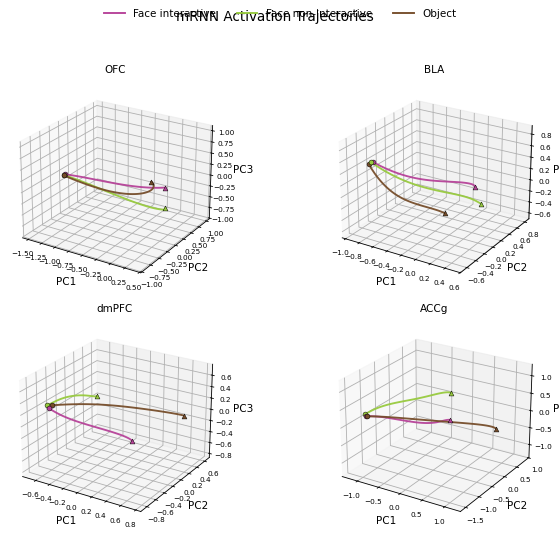

In [6]:
plot_settings = FixationMRNNDiagnosticPlotSettings()
raw_activation_fig, raw_activation_axes = plot_fixation_mrnn_activation_trajectories_3d(
    raw_replay,
    settings=plot_settings,
)
display_figure(raw_activation_fig)

Plot two-dimensional nonlinear flow fields for the raw firing-rate model at the time bin closest to fixation onset (`t = 0`). Each subplot is one target region and fixation condition, with arrows showing local state-space velocity in the region's flow-field PCA plane. Increase `num_points` for a denser grid or `plot_settings.flow_arrow_scale` for longer arrows.

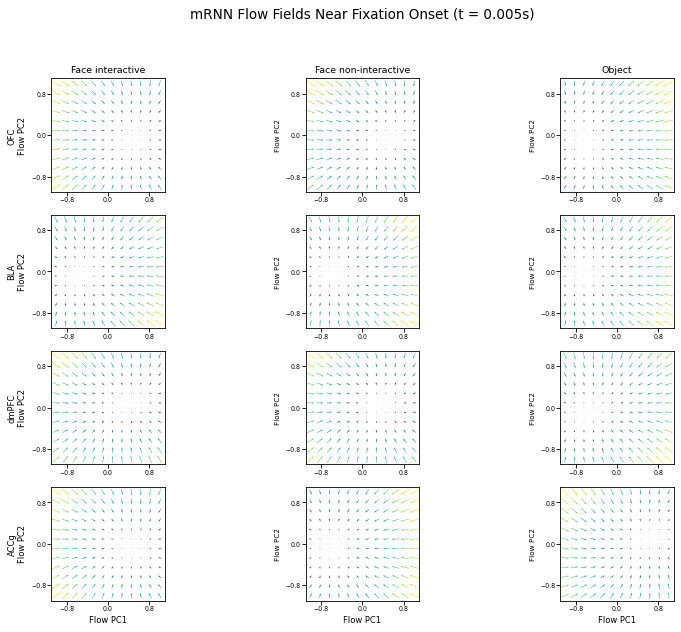

In [7]:
raw_flow_fig, raw_flow_axes = plot_fixation_mrnn_flow_fields_at_time(
    raw_replay,
    time_s=0.0,
    num_points=12,
    settings=plot_settings,
)
display_figure(raw_flow_fig)

Plot activation PC timecourses together with stacked relative recurrent current influence. Each stackplot shows how strongly the source regions contribute to the target region's recurrent input at each time bin.

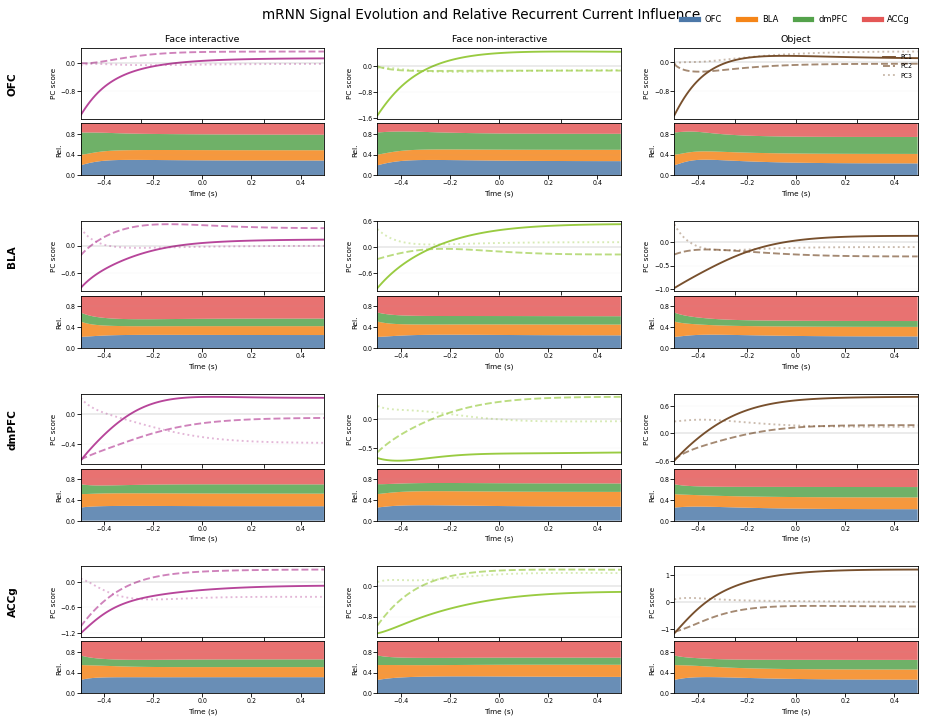

In [8]:
raw_current_fig, raw_current_axes = plot_fixation_mrnn_current_influence(
    raw_replay,
    current_vectors=raw_current_vectors,
    settings=plot_settings,
)
display_figure(raw_current_fig)

Average the relative current influence over time and show one pie chart per target region and fixation condition. The slice labels report the time-averaged percentage contribution from each source region.

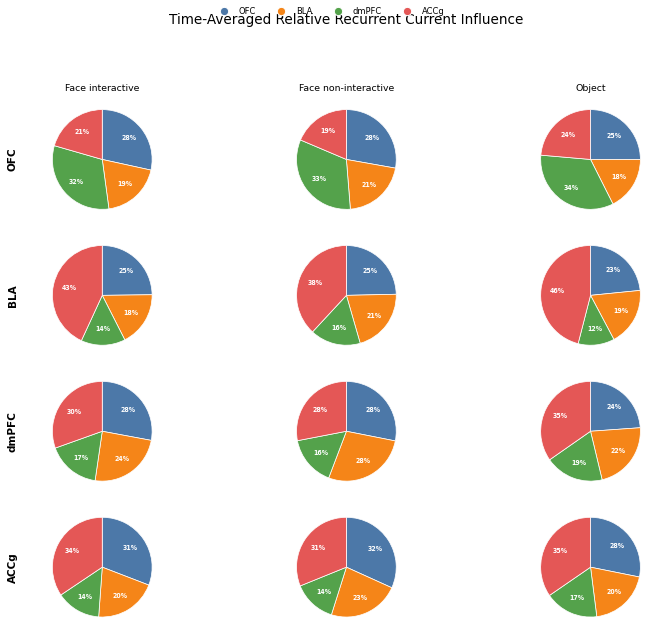

In [9]:
raw_pie_fig, raw_pie_axes = plot_fixation_mrnn_average_current_influence_pies(
    raw_replay,
    current_vectors=raw_current_vectors,
    settings=plot_settings,
)
display_figure(raw_pie_fig)

## Region-PC Scratch Run

Configure and train the matching scratch mRNN for region-PC targets. This uses the same one-hot inputs and region shuffling logic, but each output head predicts the shared PC-dimensional latent trace for its region.

In [10]:
pc_settings = settings_from_config(cfg)
pc_settings.dataset_cfg_path = settings.dataset_cfg_path
pc_settings.device = settings.device
pc_settings.epochs = 50
pc_settings.hidden_units = 8
pc_settings.seed = 223456
pc_settings.target_mode = "region_pcs"

summarize_training_setup("Region-PC mRNN setup", pc_settings, targets)

pc_result = train_fixation_mrnn_scratch(
    pc_settings,
    scratch_id="smoke_region_pcs",
    overwrite=True,
)
pc_result["run_dir"], pc_result["history"].tail()

Region-PC mRNN setup
target mode: region_pcs
epochs: 50; seed: 223456; device: auto
model: activation=softplus, dt=10.0, tau=100.0, spectral_radius=1.3
canonical region order (4): ('ofc', 'bla', 'dmpfc', 'accg')
internal region order (4): ('ofc', 'dmpfc', 'bla', 'accg')
region shuffle seed: 223456; feature shuffle seed: 1223459
input tensor shape: (3, 100, 3)


,region,hidden units,target shape,output dims,feature order shuffled,canonical feature snippet,internal feature snippet
0,ofc,8,"(3, 100, 42)",42,True,"ofc_pc1, ofc_pc2, ofc_pc3, ofc_pc4","ofc_pc30, ofc_pc4, ofc_pc5, ofc_pc17"
1,bla,8,"(3, 100, 42)",42,True,"bla_pc1, bla_pc2, bla_pc3, bla_pc4","bla_pc26, bla_pc32, bla_pc38, bla_pc36"
2,dmpfc,8,"(3, 100, 42)",42,True,"dmpfc_pc1, dmpfc_pc2, dmpfc_pc3, dmpfc_pc4","dmpfc_pc40, dmpfc_pc27, dmpfc_pc20, dmpfc_pc29"
3,accg,8,"(3, 100, 42)",42,True,"accg_pc1, accg_pc2, accg_pc3, accg_pc4","accg_pc9, accg_pc33, accg_pc23, accg_pc40"


(PosixPath('/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/smoke_region_pcs'),
     epoch      loss  mse_loss  rate_loss  weight_loss
 45     46  0.072081  0.071578   0.000053      0.00045
 46     47  0.070512  0.070010   0.000052      0.00045
 47     48  0.068994  0.068492   0.000052      0.00045
 48     49  0.067525  0.067023   0.000052      0.00045
 49     50  0.066102  0.065600   0.000052      0.00045)

Reload the region-PC checkpoint on CPU and restore canonical region and feature order.

In [11]:
pc_replay = replay_fixation_mrnn_run(pc_result["run_dir"], device="cpu")
summarize_replay("Region-PC replay", pc_replay)

Region-PC replay
trained target mode: region_pcs
canonical region order: ('ofc', 'bla', 'dmpfc', 'accg')
internal region order: ('ofc', 'dmpfc', 'bla', 'accg')
input tensor shape: (3, 100, 3)
canonical replay output shapes: {'ofc': (3, 100, 42), 'bla': (3, 100, 42), 'dmpfc': (3, 100, 42), 'accg': (3, 100, 42)}


Compute recurrent current decompositions for the region-PC replay. These vectors are reused by the current influence and time-averaged pie plots below.

In [12]:
_pc_current_df, pc_current_vectors = compute_fixation_mrnn_currents(pc_replay)

## Region-PC Diagnostic Plots

Plot the hidden-state activation trajectories for the region-PC model in each region's top three activation PCs. This checks whether the trained dynamics occupy condition-specific paths in low-dimensional state space.

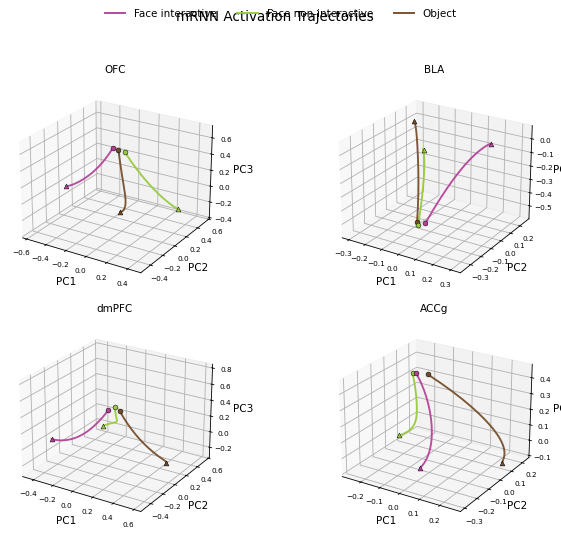

In [13]:
pc_activation_fig, pc_activation_axes = plot_fixation_mrnn_activation_trajectories_3d(
    pc_replay,
    settings=plot_settings,
)
display_figure(pc_activation_fig)

Plot the region-PC model's nonlinear flow fields at the time bin closest to fixation onset (`t = 0`). The grid uses the same region-by-condition layout as the raw firing-rate flow-field plot. Increase `num_points` for a denser grid or `plot_settings.flow_arrow_scale` for longer arrows.

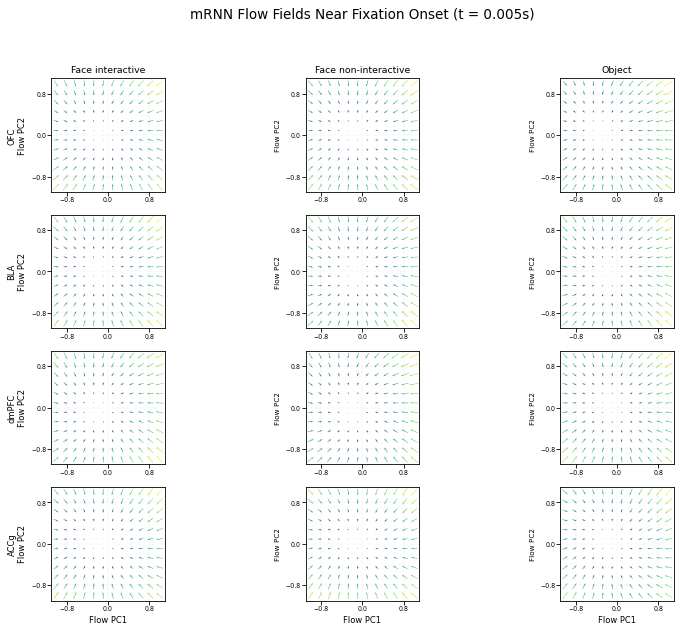

In [14]:
pc_flow_fig, pc_flow_axes = plot_fixation_mrnn_flow_fields_at_time(
    pc_replay,
    time_s=0.0,
    num_points=12,
    settings=plot_settings,
)
display_figure(pc_flow_fig)

Plot signal evolution and relative recurrent current influence for the region-PC model. The upper panels summarize activation PCs over time, and the lower panels show source-region influence fractions.

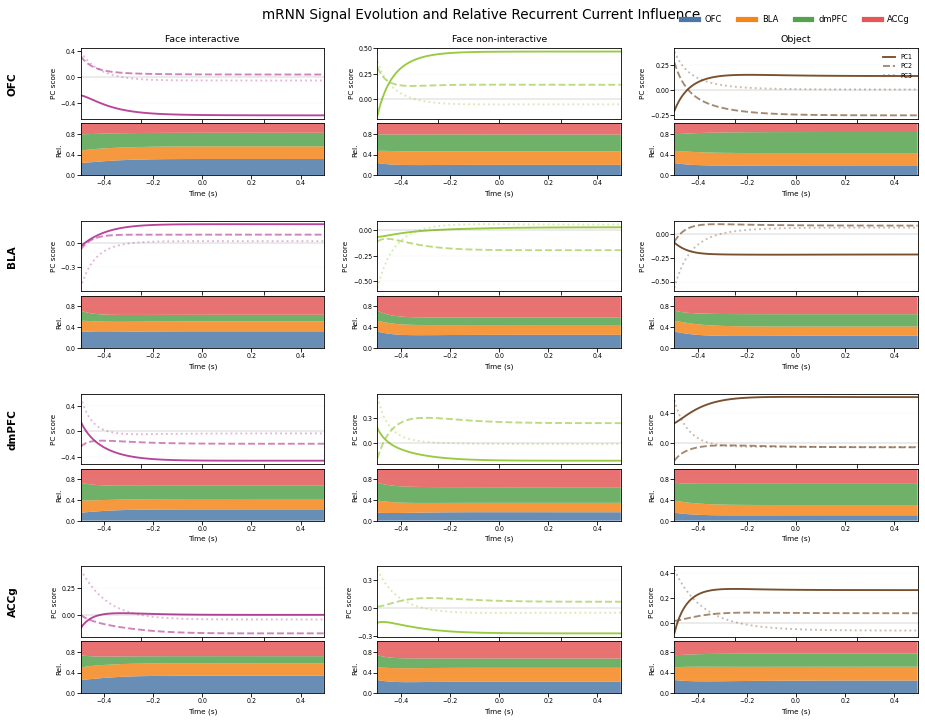

In [15]:
pc_current_fig, pc_current_axes = plot_fixation_mrnn_current_influence(
    pc_replay,
    current_vectors=pc_current_vectors,
    settings=plot_settings,
)
display_figure(pc_current_fig)

Collapse each region-PC current influence stackplot across time into a percentage-labeled pie chart, giving a compact summary of average source-region influence by target region and fixation condition.

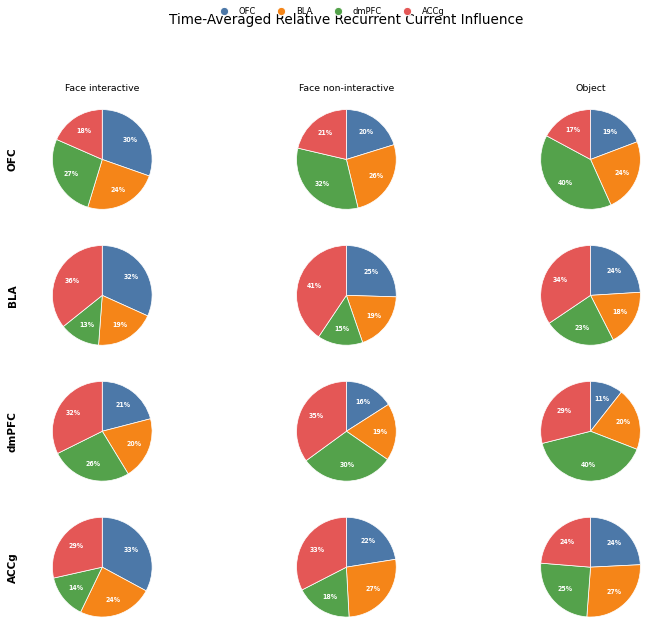

In [16]:
pc_pie_fig, pc_pie_axes = plot_fixation_mrnn_average_current_influence_pies(
    pc_replay,
    current_vectors=pc_current_vectors,
    settings=plot_settings,
)
display_figure(pc_pie_fig)